<a href="https://colab.research.google.com/github/ibrahimbarghout/robust-ecg-domain-generalization/blob/main/notebooks/06_signal_inspection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# PTB-XL Research Project
## 6. Signal Inspection

#This notebook examines the raw 12-lead ECG recordings in the PTB-XL
#dataset before any preprocessing is applied.

#The analysis focuses on:

#- ECG signal structure and dimensions
#- Sampling frequency and recording duration
#- Lead configuration
#- Signal amplitude and basic statistics
#- Representative ECG waveforms
#- Baseline drift and noise characteristics
#- Differences between relatively clean and noisy recordings

#No signal preprocessing is performed in this notebook.

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!pip install wfdb -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.0 MB/s eta 0:00:00


In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb

In [6]:
print("WFDB version:", wfdb.__version__)

WFDB version: 4.3.1


In [7]:
PROJECT_PATH = "/content/drive/MyDrive/PTB-XL Research Project"

DATA_PATH = os.path.join(
    PROJECT_PATH,
    "data",
    "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"
)

RESULTS_PATH = os.path.join(
    PROJECT_PATH,
    "results"
)

print("Dataset path:")
print(DATA_PATH)

print("\nDataset exists:", os.path.isdir(DATA_PATH))

print("\nResults path:")
print(RESULTS_PATH)

print("\nResults directory exists:", os.path.isdir(RESULTS_PATH))

Dataset path:
/content/drive/MyDrive/PTB-XL Research Project/data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3

Dataset exists: True

Results path:
/content/drive/MyDrive/PTB-XL Research Project/results

Results directory exists: True


In [8]:
df = pd.read_csv(
    os.path.join(DATA_PATH, "ptbxl_database.csv"),
    index_col="ecg_id"
)

print("ECG records:", len(df))
print("Unique patients:", df["patient_id"].nunique())

ECG records: 21799
Unique patients: 18869


In [9]:
SPLIT_PATH = os.path.join(
    RESULTS_PATH,
    "ptbxl_patient_independent_split.csv"
)

split_df = pd.read_csv(SPLIT_PATH)

print("Split records:", len(split_df))

print("\nSplit distribution:")
print(split_df["split"].value_counts())

Split records: 21799

Split distribution:
split
train         17418
test           2198
validation     2183
Name: count, dtype: int64


In [10]:
print("Low-resolution example:")
print(df["filename_lr"].head())

print("\nHigh-resolution example:")
print(df["filename_hr"].head())

Low-resolution example:
ecg_id
1    records100/00000/00001_lr
2    records100/00000/00002_lr
3    records100/00000/00003_lr
4    records100/00000/00004_lr
5    records100/00000/00005_lr
Name: filename_lr, dtype: object

High-resolution example:
ecg_id
1    records500/00000/00001_hr
2    records500/00000/00002_hr
3    records500/00000/00003_hr
4    records500/00000/00004_hr
5    records500/00000/00005_hr
Name: filename_hr, dtype: object


In [11]:
for ecg_id in df.index[:5]:

    relative_path = df.loc[ecg_id, "filename_hr"]

    full_path = os.path.join(
        DATA_PATH,
        relative_path
    )

    print(
        f"ECG {ecg_id}:",
        os.path.exists(full_path + ".hea"),
        full_path
    )

ECG 1: True /content/drive/MyDrive/PTB-XL Research Project/data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/records500/00000/00001_hr
ECG 2: True /content/drive/MyDrive/PTB-XL Research Project/data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/records500/00000/00002_hr
ECG 3: True /content/drive/MyDrive/PTB-XL Research Project/data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/records500/00000/00003_hr
ECG 4: True /content/drive/MyDrive/PTB-XL Research Project/data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/records500/00000/00004_hr
ECG 5: True /content/drive/MyDrive/PTB-XL Research Project/data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/records500/00000/00005_hr


In [14]:
# ============================================
# 4. Load and inspect one ECG waveform
# ============================================

import wfdb
import numpy as np
import matplotlib.pyplot as plt

ecg_id = 1

record_path = os.path.join(
    DATA_PATH,
    df.loc[ecg_id, "filename_hr"]
)

record = wfdb.rdrecord(record_path)

print("ECG ID:", ecg_id)
print("Sampling frequency:", record.fs, "Hz")
print("Number of samples:", record.sig_len)
print("Number of leads:", record.n_sig)
print("Duration:", record.sig_len / record.fs, "seconds")

print("\nLead names:")
print(record.sig_name)

print("\nSignal shape:")
print(record.p_signal.shape)

ECG ID: 1
Sampling frequency: 500 Hz
Number of samples: 5000
Number of leads: 12
Duration: 10.0 seconds

Lead names:
['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

Signal shape:
(5000, 12)


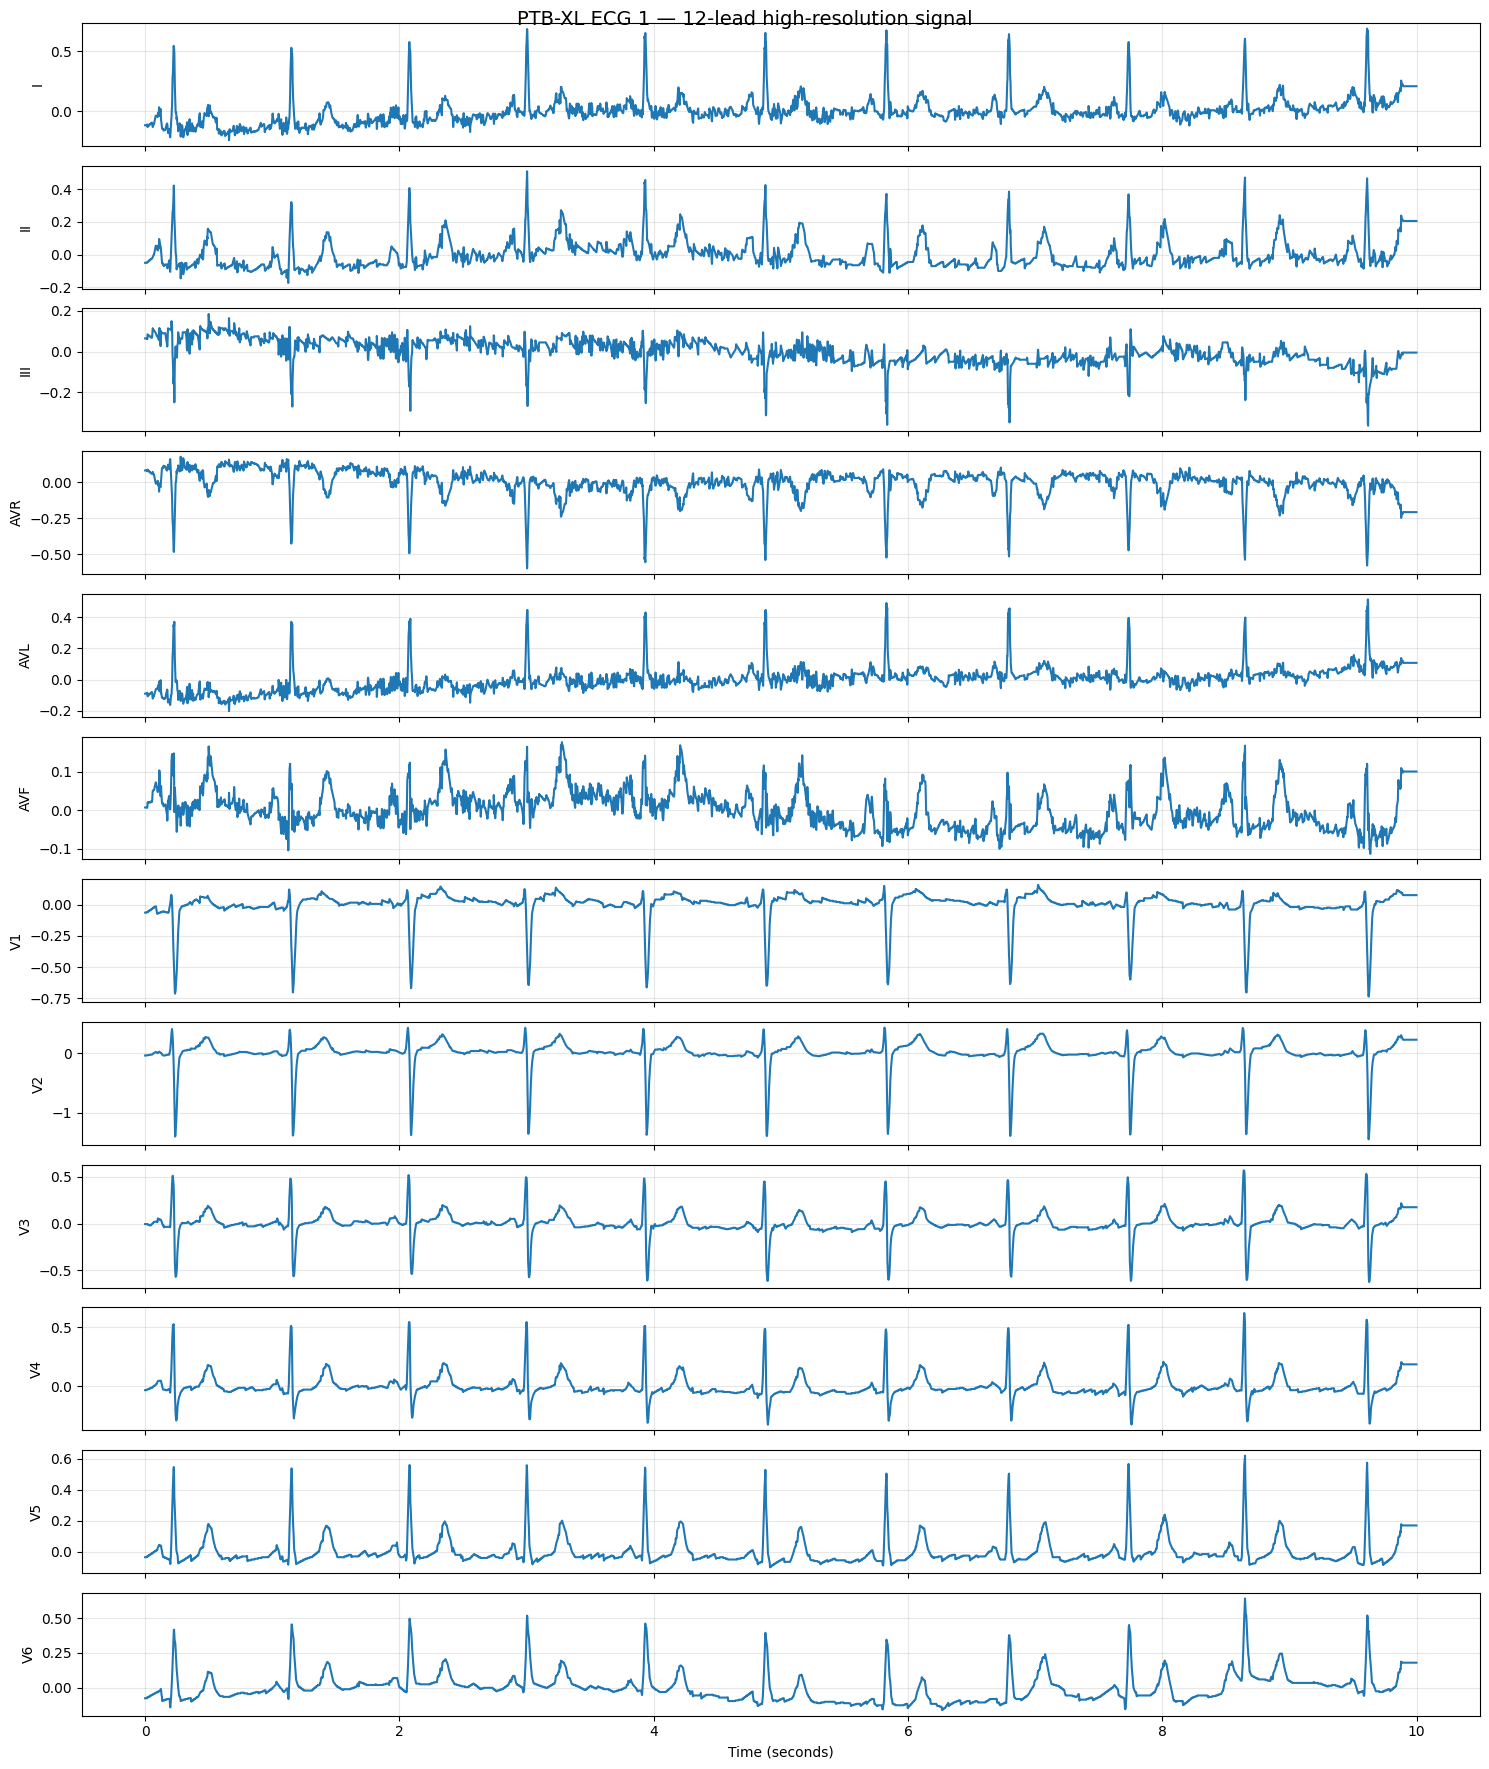

In [15]:
# ============================================
# Plot all 12 ECG leads
# ============================================

signals = record.p_signal
time = np.arange(record.sig_len) / record.fs

fig, axes = plt.subplots(
    12, 1,
    figsize=(15, 18),
    sharex=True
)

for i, lead in enumerate(record.sig_name):
    axes[i].plot(time, signals[:, i])
    axes[i].set_ylabel(lead)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (seconds)")

plt.suptitle(
    f"PTB-XL ECG {ecg_id} — 12-lead high-resolution signal",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [16]:
# ============================================
# Basic signal statistics
# ============================================

print("Signal quality inspection for ECG", ecg_id)
print("=" * 50)

for i, lead in enumerate(record.sig_name):
    signal = signals[:, i]

    print(
        f"{lead:4s} | "
        f"Min: {signal.min():8.3f} mV | "
        f"Max: {signal.max():8.3f} mV | "
        f"Mean: {signal.mean():8.3f} mV | "
        f"Std: {signal.std():8.3f} mV"
    )

Signal quality inspection for ECG 1
I    | Min:   -0.240 mV | Max:    0.690 mV | Mean:    0.003 mV | Std:    0.112 mV
II   | Min:   -0.173 mV | Max:    0.508 mV | Mean:    0.002 mV | Std:    0.086 mV
III  | Min:   -0.365 mV | Max:    0.185 mV | Mean:   -0.000 mV | Std:    0.060 mV
AVR  | Min:   -0.597 mV | Max:    0.177 mV | Mean:   -0.002 mV | Std:    0.095 mV
AVL  | Min:   -0.202 mV | Max:    0.513 mV | Mean:    0.002 mV | Std:    0.078 mV
AVF  | Min:   -0.113 mV | Max:    0.176 mV | Mean:    0.001 mV | Std:    0.049 mV
V1   | Min:   -0.736 mV | Max:    0.157 mV | Mean:   -0.001 mV | Std:    0.113 mV
V2   | Min:   -1.444 mV | Max:    0.428 mV | Mean:    0.009 mV | Std:    0.216 mV
V3   | Min:   -0.625 mV | Max:    0.570 mV | Mean:   -0.000 mV | Std:    0.119 mV
V4   | Min:   -0.329 mV | Max:    0.622 mV | Mean:   -0.003 mV | Std:    0.097 mV
V5   | Min:   -0.101 mV | Max:    0.620 mV | Mean:    0.001 mV | Std:    0.091 mV
V6   | Min:   -0.160 mV | Max:    0.640 mV | Mean:    0.002 mV

In [17]:
# ============================================
# Check for missing or invalid signal values
# ============================================

print("NaN values:", np.isnan(signals).sum())
print("Infinite values:", np.isinf(signals).sum())

print("\nOverall signal range:")
print("Minimum:", signals.min(), "mV")
print("Maximum:", signals.max(), "mV")

NaN values: 0
Infinite values: 0

Overall signal range:
Minimum: -1.444 mV
Maximum: 0.69 mV


In [18]:
# ============================================
# Inspect multiple ECG recordings
# ============================================

sample_ecg_ids = [1, 100, 1000, 5000, 10000]

for ecg_id in sample_ecg_ids:

    record_path = os.path.join(
        DATA_PATH,
        df.loc[ecg_id, "filename_hr"]
    )

    record = wfdb.rdrecord(record_path)

    print(f"\nECG {ecg_id}")
    print("-" * 40)
    print("Sampling frequency:", record.fs, "Hz")
    print("Samples:", record.sig_len)
    print("Leads:", record.n_sig)
    print("Duration:", record.sig_len / record.fs, "seconds")
    print("Signal shape:", record.p_signal.shape)
    print(
        "Range:",
        f"{record.p_signal.min():.3f}",
        "to",
        f"{record.p_signal.max():.3f}",
        "mV"
    )


ECG 1
----------------------------------------
Sampling frequency: 500 Hz
Samples: 5000
Leads: 12
Duration: 10.0 seconds
Signal shape: (5000, 12)
Range: -1.444 to 0.690 mV

ECG 100
----------------------------------------
Sampling frequency: 500 Hz
Samples: 5000
Leads: 12
Duration: 10.0 seconds
Signal shape: (5000, 12)
Range: -1.870 to 0.883 mV

ECG 1000
----------------------------------------
Sampling frequency: 500 Hz
Samples: 5000
Leads: 12
Duration: 10.0 seconds
Signal shape: (5000, 12)
Range: -1.012 to 1.573 mV

ECG 5000
----------------------------------------
Sampling frequency: 500 Hz
Samples: 5000
Leads: 12
Duration: 10.0 seconds
Signal shape: (5000, 12)
Range: -1.420 to 2.568 mV

ECG 10000
----------------------------------------
Sampling frequency: 500 Hz
Samples: 5000
Leads: 12
Duration: 10.0 seconds
Signal shape: (5000, 12)
Range: -1.075 to 1.052 mV


In [19]:
# ============================================
# Compare low-resolution and high-resolution ECG
# ============================================

ecg_id = 1

lr_path = os.path.join(
    DATA_PATH,
    df.loc[ecg_id, "filename_lr"]
)

hr_path = os.path.join(
    DATA_PATH,
    df.loc[ecg_id, "filename_hr"]
)

record_lr = wfdb.rdrecord(lr_path)
record_hr = wfdb.rdrecord(hr_path)

print("ECG ID:", ecg_id)

print("\nLow-resolution:")
print("Sampling frequency:", record_lr.fs, "Hz")
print("Samples:", record_lr.sig_len)
print("Leads:", record_lr.n_sig)
print("Duration:", record_lr.sig_len / record_lr.fs, "seconds")
print("Shape:", record_lr.p_signal.shape)

print("\nHigh-resolution:")
print("Sampling frequency:", record_hr.fs, "Hz")
print("Samples:", record_hr.sig_len)
print("Leads:", record_hr.n_sig)
print("Duration:", record_hr.sig_len / record_hr.fs, "seconds")
print("Shape:", record_hr.p_signal.shape)

ECG ID: 1

Low-resolution:
Sampling frequency: 100 Hz
Samples: 1000
Leads: 12
Duration: 10.0 seconds
Shape: (1000, 12)

High-resolution:
Sampling frequency: 500 Hz
Samples: 5000
Leads: 12
Duration: 10.0 seconds
Shape: (5000, 12)


In [20]:
# ============================================
# Inspect WFDB record metadata
# ============================================

ecg_id = 1

record_path = os.path.join(
    DATA_PATH,
    df.loc[ecg_id, "filename_hr"]
)

record = wfdb.rdrecord(record_path)

print("WFDB record metadata")
print("=" * 50)

print("Record name:", record.record_name)
print("Sampling frequency:", record.fs)
print("Number of signals:", record.n_sig)
print("Signal length:", record.sig_len)

print("\nLead names:")
print(record.sig_name)

print("\nUnits:")
print(record.units)

print("\nGain:")
print(record.adc_gain)

print("\nBaseline:")
print(record.baseline)

WFDB record metadata
Record name: 00001_hr
Sampling frequency: 500
Number of signals: 12
Signal length: 5000

Lead names:
['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

Units:
['mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV']

Gain:
[1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0]

Baseline:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [22]:
# ============================================
# Load diagnostic targets for signal inspection
# ============================================

targets_path = os.path.join(
    RESULTS_PATH,
    "ptbxl_diagnostic_targets.csv"
)

targets = pd.read_csv(
    targets_path,
    index_col="ecg_id"
)

print("Targets loaded:", os.path.exists(targets_path))
print("Target shape:", targets.shape)
print("Target columns:", targets.columns.tolist())

Targets loaded: True
Target shape: (21799, 7)
Target columns: ['NORM', 'MI', 'STTC', 'CD', 'HYP', 'ABNORMAL', 'REFERENCE_NORMAL']


In [23]:
# ============================================
# Connect ECG waveform to diagnostic labels
# ============================================

ecg_id = 1

print("ECG ID:", ecg_id)

print("\nDiagnostic targets:")
display(targets.loc[[ecg_id]])

print("\nOriginal SCP codes:")
print(df.loc[ecg_id, "scp_codes"])

ECG ID: 1

Diagnostic targets:


,NORM,MI,STTC,CD,HYP,ABNORMAL,REFERENCE_NORMAL
ecg_id,,,,,,,
1,1,0,0,0,0,0,1



Original SCP codes:
{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}


In [24]:
# ============================================
# Select representative ECGs by diagnostic class
# ============================================

diagnostic_classes = ["NORM", "MI", "STTC", "CD", "HYP"]

representative_ecgs = {}

for class_name in diagnostic_classes:
    candidates = targets.index[targets[class_name] == 1]

    if len(candidates) > 0:
        representative_ecgs[class_name] = candidates[0]

print("Representative ECGs:")
for class_name, ecg_id in representative_ecgs.items():
    print(f"{class_name}: ECG {ecg_id}")

Representative ECGs:
NORM: ECG 1
MI: ECG 8
STTC: ECG 22
CD: ECG 32
HYP: ECG 30


In [25]:
# ============================================
# Inspect representative ECGs
# ============================================

for class_name, ecg_id in representative_ecgs.items():

    record_path = os.path.join(
        DATA_PATH,
        df.loc[ecg_id, "filename_hr"]
    )

    record = wfdb.rdrecord(record_path)

    print("\n" + "=" * 60)
    print(f"{class_name} — ECG {ecg_id}")
    print("=" * 60)

    print("Targets:")
    print(targets.loc[ecg_id].to_dict())

    print("\nOriginal SCP codes:")
    print(df.loc[ecg_id, "scp_codes"])

    print("\nSignal:")
    print(f"Sampling frequency: {record.fs} Hz")
    print(f"Shape: {record.p_signal.shape}")
    print(f"Range: {record.p_signal.min():.3f} to {record.p_signal.max():.3f} mV")


NORM — ECG 1
Targets:
{'NORM': 1, 'MI': 0, 'STTC': 0, 'CD': 0, 'HYP': 0, 'ABNORMAL': 0, 'REFERENCE_NORMAL': 1}

Original SCP codes:
{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}

Signal:
Sampling frequency: 500 Hz
Shape: (5000, 12)
Range: -1.444 to 0.690 mV

MI — ECG 8
Targets:
{'NORM': 0, 'MI': 1, 'STTC': 0, 'CD': 0, 'HYP': 0, 'ABNORMAL': 1, 'REFERENCE_NORMAL': 0}

Original SCP codes:
{'IMI': 35.0, 'ABQRS': 0.0, 'SR': 0.0}

Signal:
Sampling frequency: 500 Hz
Shape: (5000, 12)
Range: -2.566 to 1.280 mV

STTC — ECG 22
Targets:
{'NORM': 0, 'MI': 0, 'STTC': 1, 'CD': 0, 'HYP': 0, 'ABNORMAL': 1, 'REFERENCE_NORMAL': 0}

Original SCP codes:
{'NDT': 100.0, 'SR': 0.0}

Signal:
Sampling frequency: 500 Hz
Shape: (5000, 12)
Range: -2.039 to 0.813 mV

CD — ECG 32
Targets:
{'NORM': 0, 'MI': 0, 'STTC': 0, 'CD': 1, 'HYP': 0, 'ABNORMAL': 1, 'REFERENCE_NORMAL': 0}

Original SCP codes:
{'LPFB': 100.0, 'SR': 0.0}

Signal:
Sampling frequency: 500 Hz
Shape: (5000, 12)
Range: -2.927 to 1.793 mV

HYP — ECG 30
Tar

In [26]:
# ============================================
# Inspect a multilabel diagnostic ECG
# ============================================

target_class_names = ["NORM", "MI", "STTC", "CD", "HYP"]

# Find ECGs with at least two diagnostic classes
diagnostic_label_count = targets[target_class_names].sum(axis=1)

multilabel_ecgs = diagnostic_label_count[
    diagnostic_label_count >= 2
].index

# Select the first multilabel ECG
ecg_id = multilabel_ecgs[0]

print("Selected ECG:", ecg_id)

print("\nDiagnostic targets:")
print(targets.loc[ecg_id])

print("\nOriginal SCP codes:")
print(df.loc[ecg_id, "scp_codes"])

record_path = os.path.join(
    DATA_PATH,
    df.loc[ecg_id, "filename_hr"]
)

record = wfdb.rdrecord(record_path)

print("\nSignal:")
print("Sampling frequency:", record.fs, "Hz")
print("Shape:", record.p_signal.shape)
print(
    f"Range: {record.p_signal.min():.3f} "
    f"to {record.p_signal.max():.3f} mV"
)

Selected ECG: 39

Diagnostic targets:
NORM                0
MI                  1
STTC                1
CD                  0
HYP                 0
ABNORMAL            1
REFERENCE_NORMAL    0
Name: 39, dtype: int64

Original SCP codes:
{'IMI': 15.0, 'LNGQT': 100.0, 'NST_': 100.0, 'DIG': 100.0, 'ABQRS': 0.0, 'SR': 0.0}

Signal:
Sampling frequency: 500 Hz
Shape: (5000, 12)
Range: -2.011 to 1.545 mV


In [27]:
## 6.8 Signal Inspection Summary

#The PTB-XL waveform data were inspected using the high-resolution 500 Hz recordings.

#Key observations:

#- Each ECG contains 12 standard leads.
#- High-resolution recordings contain 5,000 samples over 10 seconds.
#- Signals are provided in millivolts.
#- The inspected recordings contained no NaN or infinite signal values.
#- ECG morphology and amplitude vary across leads and recordings.
#- Mild baseline variation and differences in apparent noise levels were observed.
#- Low-resolution recordings contain 1,000 samples at 100 Hz, while high-resolution recordings contain 5,000 samples at 500 Hz.
#- The high-resolution recordings will be used as the primary signal representation for the research pipeline.
#- Diagnostic targets were successfully linked to the corresponding ECG waveforms.
#- Representative examples confirmed the presence of NORM, MI, STTC, CD, and HYP targets.
#- A single ECG can contain multiple diagnostic targets simultaneously.

#These observations support the use of a multilabel ECG classification framework based on multichannel time-series signals.

#Signal preprocessing and normalization decisions will be investigated systematically in Notebook 08 rather than being applied during exploratory signal inspection.